In [1]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

data = pd.read_csv(
    "horse_colic_normalized.csv",
    delimiter=","
)

target_col = "outcome"

data = data.dropna(subset=[target_col])

display(data.head())

,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


In [2]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=[target_col])
y = data[target_col]

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

boosting_model = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred = boosting_model.predict(X_test)

y_prob = boosting_model.predict_proba(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

print('\nClassification report:')
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.6891891891891891

Classification report:
              precision    recall  f1-score   support

         1.0       0.80      0.78      0.79        45
         2.0       0.52      0.67      0.59        18
         3.0       0.57      0.36      0.44        11

    accuracy                           0.69        74
   macro avg       0.63      0.60      0.61        74
weighted avg       0.70      0.69      0.69        74



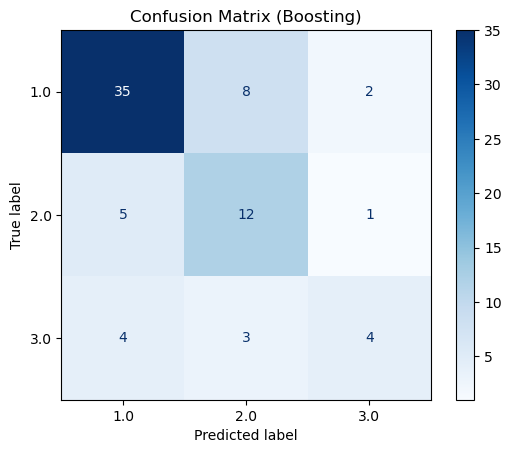

In [3]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=boosting_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix (Boosting)')
plt.grid(False)
plt.show()

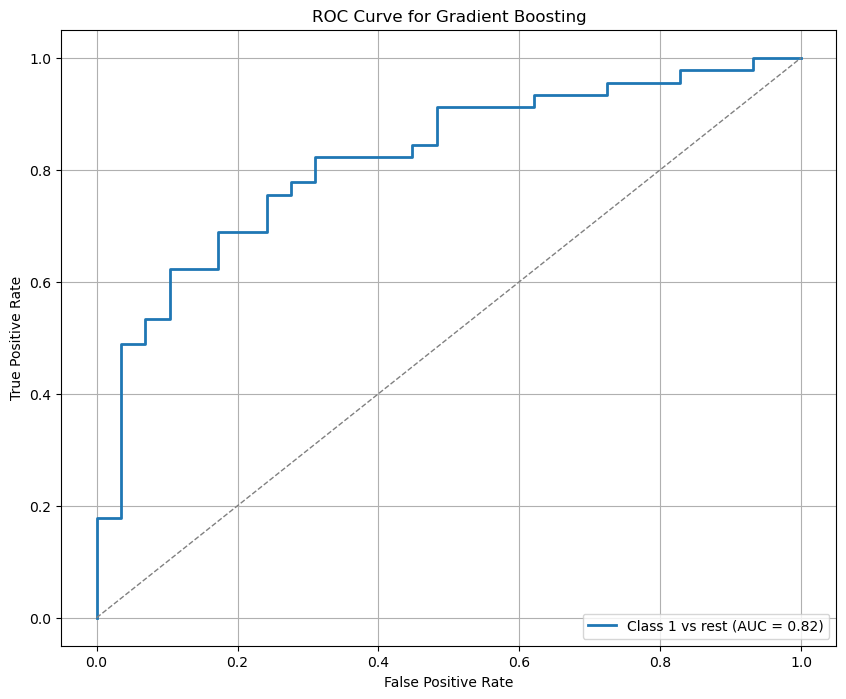

In [4]:
positive_class = 1

y_test_binary = (
    y_test == positive_class
).astype(int)

positive_class_index = list(
    boosting_model.classes_
).index(positive_class)

y_score = y_prob[:, positive_class_index]

fpr, tpr, _ = roc_curve(
    y_test_binary,
    y_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'Class {positive_class} vs rest (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='grey',
    linestyle='--',
    lw=1
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve for Gradient Boosting')

plt.legend(loc='lower right')
plt.grid()

plt.show()